# Introduction to Neural Networks

**Assignment**: 2

**Group 3**: Object Detection with YOLOv5 on Pascal VOC 2012

March 2026

## Import libraries

In [8]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor

## Dataset

In [4]:

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load annotations
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                class_label, x, y, w, h = map(float, line.strip().split())
                boxes.append([class_label, x, y, w, h])

        if self.transforms:
            image = self.transforms(image)
        return image, torch.tensor(boxes)

In [9]:
# Example: Initialize DataLoader

train_dataset = YOLODataset(img_dir="Pascal VOC 2012.v1/train/images", label_dir="Pascal VOC 2012.v1/train/labels", transforms=ToTensor())

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

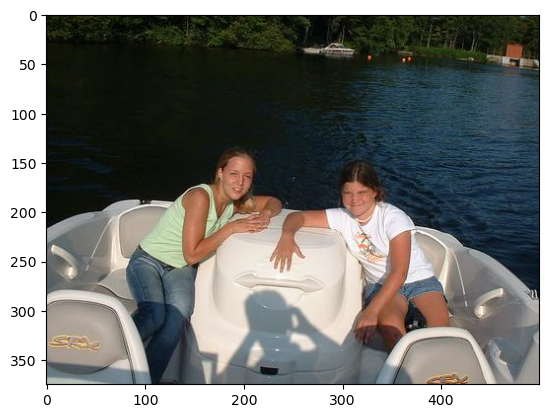

tensor([[3.0000, 0.5700, 0.0960, 0.1160, 0.0480],
        [3.0000, 0.4990, 0.7467, 0.9980, 0.5013]])

In [15]:
# View the image and its corresponding annotations

image, annotations = train_loader.dataset[6]
plt.imshow(image.permute(1, 2, 0))
plt.show()
annotations